In [1]:
import pandas as pd
import numpy as np
import pycountry

In [2]:
# PyCountry mapping
records = []
for c in pycountry.countries:
    records.append({
        "country_name": c.name,
        "iso3":         c.alpha_3,
        "iso2":         c.alpha_2,
        "iso_numeric":  c.numeric,
    })

df_iso = pd.DataFrame(records)
print(df_iso.shape)
print(df_iso.head())

(249, 4)
    country_name iso3 iso2 iso_numeric
0          Aruba  ABW   AW         533
1    Afghanistan  AFG   AF         004
2         Angola  AGO   AO         024
3       Anguilla  AIA   AI         660
4  Åland Islands  ALA   AX         248


## PIP

In [3]:
df_pip = pd.read_csv("../Raw/imf_pip_v2.csv")
df_pip

,DATASET,SERIES_CODE,OBS_MEASURE,2017,2017-S1,2017-S2,2018,2018-S1,2018-S2,2019,...,2022,2022-S1,2022-S2,2023,2023-S1,2023-S2,2024,2024-S1,2024-S2,2025-S1
0,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.ATG.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.ISL.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.BHS.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.DZA.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,IMF.STA:PIP(5.0.0),CWX.A.P_F3_L_P_USD.S121.S1.FRA.A,OBS_VALUE,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2398383,IMF.STA:PIP(5.0.0),ROU.L.P_TOTINV_P_SCC_USD.S1.S1.CHE.S,OBS_VALUE,NaN,571.442313,564.17163,NaN,546.918514,596.559919,NaN,...,NaN,747.110799,891.041091,NaN,1110.745087,1180.474895,NaN,1291.454222,1337.448300,1500.694105
2398384,IMF.STA:PIP(5.0.0),ROU.L.P_TOTINV_P_SCC_USD.S1.S1.ZAF.S,OBS_VALUE,NaN,2.220104,2.59840,NaN,84.960486,50.637642,NaN,...,NaN,0.794509,0.941534,NaN,1.055030,0.000000,NaN,2.197700,2.027319,2.249668
2398385,IMF.STA:PIP(5.0.0),ROU.L.P_F51_P_SCC_USD.S1.S1.ARG.S,OBS_VALUE,NaN,0.000000,0.00000,NaN,0.000000,0.000000,NaN,...,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
2398386,IMF.STA:PIP(5.0.0),ROU.L.P_TOTINV_P_SCC_USD.S1.S1.BRA.S,OBS_VALUE,NaN,0.031647,NaN,NaN,NaN,0.071977,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.205699,0.232956


In [4]:
# We need to extract the country codes from the
# SERIES_CODE. So we will inspect the unique
# values to learn the pattern.
df_pip["SERIES_CODE"].sample(frac=1).iloc[:10].apply(lambda x: x.split(".")).values

array([list(['KAZ', 'A', 'P_F51_P_USD', 'S12QU', 'S1', 'CRI', 'S']),
       list(['SVK', 'A', 'P_TOTINV_P_USD', 'S122', 'S1', 'MNE', 'A']),
       list(['EST', 'A', 'P_F3_P_USD', 'S1', 'S12', 'PAN', 'S']),
       list(['AUT', 'A', 'P_F51_P_USD', 'S12P', 'S1', 'MYS', 'A']),
       list(['MUS', 'A', 'P_F3_P_USD', 'S123', 'S1', 'KIR', 'S']),
       list(['MKD', 'A', 'P_F51_P_USD', 'S15', 'S1', 'KNA', 'A']),
       list(['GUY', 'L', 'P_TOTINV_P_SCC_USD', 'S1', 'S1', 'SVK', 'S']),
       list(['ZAF', 'A', 'P_TOTINV_P_USD', 'S1V', 'S1', 'GNQ', 'S']),
       list(['HUN', 'A', 'P_F51_P_USD', 'S12QU', 'S1', 'EST', 'A']),
       list(['MYS', 'A', 'P_F51_P_USD', 'S122', 'S12C', 'CAN', 'A'])],
      dtype=object)

In [5]:
# We need the first and sixth elements
# where the first is the origin country 
# and the sixth is the destination country.
df_pip["iso3_i"] = df_pip["SERIES_CODE"].apply(lambda x: x.split(".")[0])
df_pip["iso3_j"] = df_pip["SERIES_CODE"].apply(lambda x: x.split(".")[5])

df_pip[["SERIES_CODE", "iso3_i", "iso3_j"]].tail()

,SERIES_CODE,iso3_i,iso3_j
2398383,ROU.L.P_TOTINV_P_SCC_USD.S1.S1.CHE.S,ROU,CHE
2398384,ROU.L.P_TOTINV_P_SCC_USD.S1.S1.ZAF.S,ROU,ZAF
2398385,ROU.L.P_F51_P_SCC_USD.S1.S1.ARG.S,ROU,ARG
2398386,ROU.L.P_TOTINV_P_SCC_USD.S1.S1.BRA.S,ROU,BRA
2398387,TX983.L.P_F3_L_P_SCC_USD.S1.S1.PAN.S,TX983,PAN


- `P_TOTINV_P_USD`: Total Portfolio Investment (Equity + Debt)
- `P_F51_P_USD`: Equity and investment fund shares
- `P_F3_L_P_USD`: Long-term debt securities
- `P_F3_S_P_USD`: Short-term debt securities

In [6]:
# Filter only for Equity and investment fund shares
# df_pip = df_pip[df_pip["SERIES_CODE"].str.contains(".P_F51_P_USD.", regex=False)]

# FIlter total portfolio
df_pip = df_pip[df_pip["SERIES_CODE"].str.contains("P_TOTINV_P_USD", regex=False)]

In [7]:
df_pip[["iso3_i", "iso3_j", "SERIES_CODE"]].nunique()

iso3_i             92
iso3_j            245
SERIES_CODE    467923
dtype: int64

In [8]:
# Now we need to melt the dataframe by
# getting the columns for each year.
yr_cols = [col for col in df_pip.columns if col.startswith("19") or col.startswith("20")]
yr_cols = [col for col in yr_cols if len(col)==4] # Only YYYY

df_pip_melted = df_pip.melt(id_vars=["SERIES_CODE", "iso3_i", "iso3_j"], value_vars=yr_cols, var_name="year", value_name="value")
# Replace 0 with nan
df_pip_melted["value"] = df_pip_melted["value"].replace(0, np.nan)
# Drop nans for value
df_pip_melted = df_pip_melted.dropna(subset=["value"])
# Drop duplicates by iso3_i, iso3_j, and year
df_pip_melted = df_pip_melted.drop_duplicates(subset=["iso3_i", "iso3_j", "year"])
df_pip_melted.describe()

,value
count,6.117200e+04
mean,1.035479e+04
std,1.447606e+05
min,-5.314051e+03
25%,1.364751e+00
50%,1.585640e+01
75%,2.156024e+02
max,6.754489e+06


In [9]:
df_pip_melted = df_pip_melted[["iso3_i", "iso3_j", "year", "value"]]
df_pip_melted

,iso3_i,iso3_j,year,value
233,CWX,G001,2017,61.320000
312,CWX,USA,2017,61.320000
481,CWX,ISR,2017,0.400000
482,CWX,PRI,2017,0.500000
484,CWX,JAM,2017,8.300000
...,...,...,...,...
3528633,SGP,LVA,2024,1.969419
3528635,SGP,SEN,2024,0.023524
3528648,SGP,LTU,2024,0.254356
3528669,SGP,MOZ,2024,0.015438


In [10]:
df_pip_melted.to_csv("../Clean/IMF_PIP.csv", index=False)

## IIP

In [11]:
df_iip = pd.read_csv("../Raw/imf_iip.csv")
df_iip.head()

,DATASET,SERIES_CODE,OBS_MEASURE,COUNTRY,INDICATOR,FUNCTIONAL_CAT,SECTOR,SERIES_NAME,2012,2012-Q1,...,2024,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025,2025-Q1,2025-Q2,2025-Q3,2025-Q4
0,IMF.STA:IIP(13.0.0),NIC.A_P.O_F2_S12R_NV.USD.A,OBS_VALUE,Nicaragua,"Other investment, Currency and deposits, Other...",NaN,NaN,NaN,NaN,NaN,...,1.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IMF.STA:IIP(13.0.0),NIC.L_P.O_F4_S13_NV.USD.A,OBS_VALUE,Nicaragua,"Other investment, Loans, General government",NaN,NaN,NaN,2337.300000,NaN,...,6793.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IMF.STA:IIP(13.0.0),NIC.L_P.O_F2_NV.USD.Q,OBS_VALUE,Nicaragua,"Other investment, Currency and deposits",NaN,NaN,NaN,NaN,404.3,...,NaN,28.5,32.3,35.5,32.0,NaN,32.8,NaN,NaN,NaN
3,IMF.STA:IIP(13.0.0),NIC.NETAL_P.NIIP_AFR.USD.A,OBS_VALUE,Nicaragua,"Net International Investment Position, Adjuste...",NaN,NaN,NaN,-10000.997938,NaN,...,-18259.494717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IMF.STA:IIP(13.0.0),NIC.A_P.O_F4_S1Z_S_NV.USD.Q,OBS_VALUE,Nicaragua,"Other investment, Loans, Other Sectors (BPM6),...",NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,NaN


In [12]:
df_iip["INDICATOR"].value_counts().head(30)

INDICATOR
International Investment Position                                                                                968
Other investment                                                                                                 968
Other investment, Currency and deposits                                                                          966
Direct investment                                                                                                958
Other investment, Loans                                                                                          958
Portfolio investment                                                                                             955
Direct investment, Equity and investment fund shares                                                             938
Other investment, Currency and deposits, Deposit taking corporations, except the Central Bank                    936
Portfolio investment, Equity and investment fund share

In [13]:
# Keep only Liabilities (L_P), in USD, Annual (A) frequency
df_iip = df_iip[
    df_iip["SERIES_CODE"].str.contains(".L_P.", regex=False) & 
    df_iip["SERIES_CODE"].str.contains(".USD.", regex=False) & 
    df_iip["SERIES_CODE"].str.endswith(".A")
]

In [14]:
# Extract the iso3 from SERIES_CODE
df_iip["iso3"] = df_iip["SERIES_CODE"].apply(lambda x: x.split(".")[0])

In [15]:
# We want the following metrics
metrics = [
    "Portfolio investment, Equity and investment fund shares",
    # "Portfolio investment, Debt securities"
]

# Make sure they both exist in dataframe
assert all(metric in df_iip["INDICATOR"].unique() for metric in metrics)

df_iip = df_iip[df_iip["INDICATOR"].isin(metrics)]

In [16]:
# Now get all the yr columns
yr_cols = [col for col in df_iip.columns if col.startswith("19") or col.startswith("20")]
yr_cols = [col for col in yr_cols if len(col)==4] # Only YYYY

df_iip_melted = df_iip.melt(id_vars=["SERIES_CODE", "iso3", "INDICATOR"], value_vars=yr_cols, var_name="year", value_name="value")
# Replace 0 with nan
df_iip_melted["value"] = df_iip_melted["value"].replace(0, np.nan)
# Drop nans for value
df_iip_melted = df_iip_melted.dropna(subset=["value"])
# Drop duplicates by iso3, INDICATOR, and year
df_iip_melted = df_iip_melted.drop_duplicates(subset=["iso3", "INDICATOR", "year"])

# Now sum the two indicators, but first assert that there is
# only one of each per year and country.
assert df_iip_melted.groupby(["iso3", "year", "INDICATOR"]).value_counts().max() == 1

df_iip_melted["value"] = df_iip_melted.groupby(["iso3", "year"])["value"].transform("sum")

df_iip_melted

,SERIES_CODE,iso3,INDICATOR,year,value
0,PHL.L_P.P_F5_MV.USD.A,PHL,"Portfolio investment, Equity and investment fu...",2012,38930.738978
1,IND.L_P.P_F5_MV.USD.A,IND,"Portfolio investment, Equity and investment fu...",2012,128932.422019
2,KEN.L_P.P_F5_MV.USD.A,KEN,"Portfolio investment, Equity and investment fu...",2012,381.742164
3,DNK.L_P.P_F5_MV.USD.A,DNK,"Portfolio investment, Equity and investment fu...",2012,107299.570603
4,BWA.L_P.P_F5_MV.USD.A,BWA,"Portfolio investment, Equity and investment fu...",2012,72.414370
...,...,...,...,...,...
2287,DMA.L_P.P_F5_MV.USD.A,DMA,"Portfolio investment, Equity and investment fu...",2025,2.740169
2289,G309.L_P.P_F5_MV.USD.A,G309,"Portfolio investment, Equity and investment fu...",2025,94.063465
2291,SVN.L_P.P_F5_MV.USD.A,SVN,"Portfolio investment, Equity and investment fu...",2025,5729.698325
2294,MKD.L_P.P_F5_MV.USD.A,MKD,"Portfolio investment, Equity and investment fu...",2025,102.647346


In [17]:
# Now to join to the pip data, we need to
# set iso3_i and iso3_j to the same value 
# as iso3 in the iip data.
df_iip_melted["iso3_i"] = df_iip_melted["iso3"]
df_iip_melted["iso3_j"] = df_iip_melted["iso3"]

In [18]:
df_iip_melted = df_iip_melted[["iso3_i", "iso3_j", "year", "value"]]

In [19]:
df_iip_melted.shape

(1670, 4)

In [20]:
# Save to clean csv
df_iip_melted.to_csv("../Clean/IMF_IIP.csv", index=False)

## Merge

In [21]:
df_full = df_pip_melted.merge(df_iip_melted, on=["iso3_i", "iso3_j", "year"], how="outer")

df_full["value"] = df_full["value_x"].combine_first(df_full["value_y"])
df_full

,iso3_i,iso3_j,year,value_x,value_y,value
0,ABW,ARE,2017,0.17000,NaN,0.170000
1,ABW,ARE,2018,0.11000,NaN,0.110000
2,ABW,ARE,2019,0.13000,NaN,0.130000
3,ABW,ARE,2020,0.11000,NaN,0.110000
4,ABW,ARE,2021,0.15653,NaN,0.156530
...,...,...,...,...,...,...
46832,ZMB,ZMB,2020,NaN,502.304393,502.304393
46833,ZMB,ZMB,2021,NaN,137.223681,137.223681
46834,ZMB,ZMB,2022,NaN,122.996420,122.996420
46835,ZMB,ZMB,2023,NaN,248.369562,248.369562


In [22]:
df_full["year"] = df_full["year"].astype(int)
df_full["value"] = df_full["value"].astype(float)

In [23]:
# print number of same and non-same
same_cnt = (df_full["iso3_i"] == df_full["iso3_j"]).sum()
non_same_cnt = (df_full["iso3_i"] != df_full["iso3_j"]).sum()
print(f"Number of same: {same_cnt}")
print(f"Number of non-same: {non_same_cnt}")

Number of same: 1671
Number of non-same: 45166


In [24]:
df_full = df_full[["iso3_i", "iso3_j", "year", "value"]]

In [25]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46837 entries, 0 to 46836
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   iso3_i  46837 non-null  object 
 1   iso3_j  46837 non-null  object 
 2   year    46837 non-null  int64  
 3   value   46837 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.4+ MB


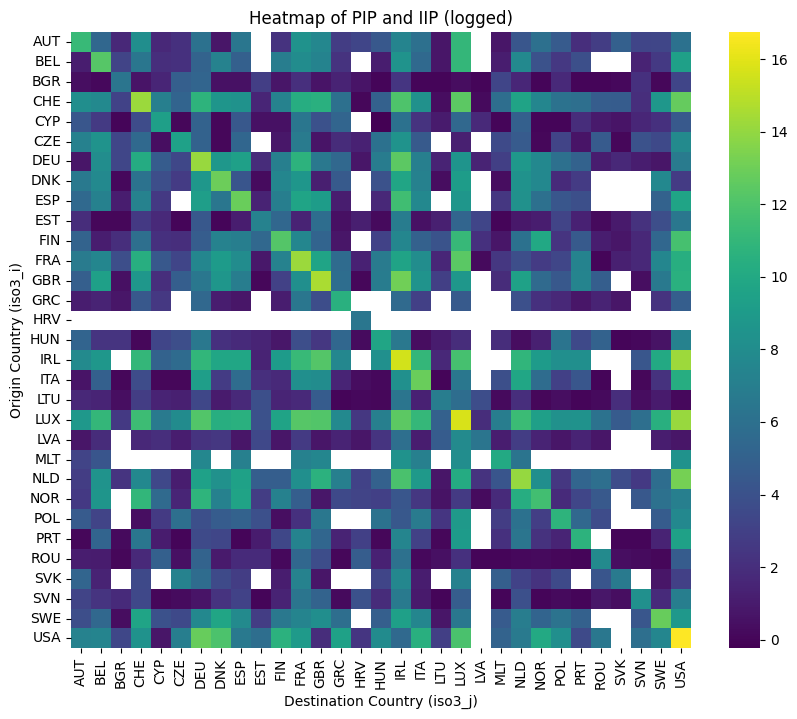

In [26]:
# plot a heatmap (logged)
import matplotlib.pyplot as plt
import seaborn as sns

EU27 = [
    'AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC',
    'HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK',
    'SVN','ESP','SWE'
]
OUTSIDE = ['USA','GBR','CHE','NOR']
COUNTRIES = EU27 + OUTSIDE

df_eu = df_full[df_full["iso3_i"].isin(COUNTRIES) & df_full["iso3_j"].isin(COUNTRIES)].copy()
df_eu = df_eu[df_eu["year"] == 2024]

plt.figure(figsize=(10, 8))
sns.heatmap(df_eu.pivot_table(index="iso3_i", columns="iso3_j", values="value", aggfunc="sum").apply(np.log1p), cmap="viridis")
plt.title("Heatmap of PIP and IIP (logged)")
plt.xlabel("Destination Country (iso3_j)")
plt.ylabel("Origin Country (iso3_i)")
plt.show()

In [27]:
eu_pivot = df_eu.pivot_table(index="iso3_i", columns="iso3_j", values="value", aggfunc="sum")

# Get diagonal / row sum
eu_pivot["row_sum"] = eu_pivot.sum(axis=1)
eu_pivot["diag"] = np.diag(eu_pivot)
eu_pivot["diag_ratio"] = eu_pivot["diag"] / eu_pivot["row_sum"]
eu_pivot[["diag_ratio"]].sort_values("diag_ratio", ascending=False)

iso3_j,diag_ratio
iso3_i,
HRV,1.000000
GRC,0.959265
USA,0.959066
DNK,0.887039
ITA,0.843972
SWE,0.843511
CYP,0.833065
HUN,0.798416
FRA,0.796226


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>iso3_j</th>
      <th>diag_ratio</th>
    </tr>
    <tr>
      <th>iso3_i</th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>USA</th>
      <td>0.963049</td>
    </tr>
    <tr>
      <th>DEU</th>
      <td>0.930788</td>
    </tr>
    <tr>
      <th>GRC</th>
      <td>0.923862</td>
    </tr>
    <tr>
      <th>DNK</th>
      <td>0.914473</td>
    </tr>
    <tr>
      <th>GBR</th>
      <td>0.913462</td>
    </tr>
    <tr>
      <th>FIN</th>
      <td>0.905674</td>
    </tr>
    <tr>
      <th>FRA</th>
      <td>0.874613</td>
    </tr>
    <tr>
      <th>IRL</th>
      <td>0.865186</td>
    </tr>
    <tr>
      <th>BEL</th>
      <td>0.843388</td>
    </tr>
    <tr>
      <th>SWE</th>
      <td>0.839801</td>
    </tr>
    <tr>
      <th>LUX</th>
      <td>0.815536</td>
    </tr>
    <tr>
      <th>MLT</th>
      <td>0.789044</td>
    </tr>
    <tr>
      <th>HUN</th>
      <td>0.787674</td>
    </tr>
    <tr>
      <th>CYP</th>
      <td>0.780375</td>
    </tr>
    <tr>
      <th>POL</th>
      <td>0.779841</td>
    </tr>
    <tr>
      <th>AUT</th>
      <td>0.776607</td>
    </tr>
    <tr>
      <th>NLD</th>
      <td>0.773328</td>
    </tr>
    <tr>
      <th>ITA</th>
      <td>0.759664</td>
    </tr>
    <tr>
      <th>ESP</th>
      <td>0.725275</td>
    </tr>
    <tr>
      <th>CHE</th>
      <td>0.624642</td>
    </tr>
    <tr>
      <th>LTU</th>
      <td>0.493197</td>
    </tr>
    <tr>
      <th>PRT</th>
      <td>0.483344</td>
    </tr>
    <tr>
      <th>SVN</th>
      <td>0.388419</td>
    </tr>
    <tr>
      <th>CZE</th>
      <td>0.347787</td>
    </tr>
    <tr>
      <th>EST</th>
      <td>0.304616</td>
    </tr>
    <tr>
      <th>NOR</th>
      <td>0.293368</td>
    </tr>
    <tr>
      <th>ROU</th>
      <td>0.290594</td>
    </tr>
    <tr>
      <th>BGR</th>
      <td>0.288351</td>
    </tr>
    <tr>
      <th>LVA</th>
      <td>0.263004</td>
    </tr>
    <tr>
      <th>SVK</th>
      <td>0.125786</td>
    </tr>
    <tr>
      <th>HRV</th>
      <td>0.075636</td>
    </tr>
  </tbody>
</table>
</div>